#**Installs**

In [1]:
!pip install torchkge
!pip install numpy
!pip install -U scikit-learn
!git clone https://github.com/villmow/datasets_knowledge_embedding.git

fatal: destination path 'datasets_knowledge_embedding' already exists and is not an empty directory.


#**Knowledge Graph**

##Use a dataset loader to load a KG you want to work with.

In [ ]:
from torchkge.utils.datasets import load_fb15k237

kg_train, kg_val, kg_test = load_fb15k237()

/opt/anaconda3/lib/python3.12/site-packages/torchkge/utils/data_redundancy.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Use the methods provided by the [KnolwedgeGraph class](https://torchkge.readthedocs.io/en/latest/reference/data.html#knowledge-graph) to inspect the KG.

### Print out the numbers of entities, relations, and facts in the training,validation, and testing sets.

In [ ]:
#Your code here

### Print the identifiers for the first 10 entities and relations (tip: ent2ix and rel2ix).

In [ ]:
print(list(kg_train.ent2ix.keys())[-10:])
print(list(kg_train.rel2ix.keys())[-10:])

['/m/0zlgm', '/m/0zlt9', '/m/0zm1', '/m/0zpfy', '/m/0zq7r', '/m/0zqq', '/m/0zqq8', '/m/0zrlp', '/m/0zygc', '/m/0zz6w']
['/tv/tv_program/genre', '/tv/tv_program/languages', '/tv/tv_program/program_creator', '/tv/tv_program/regular_cast./tv/regular_tv_appearance/actor', '/tv/tv_program/tv_producer./tv/tv_producer_term/producer_type', '/tv/tv_writer/tv_programs./tv/tv_program_writer_relationship/tv_program', '/user/alexander/philosophy/philosopher/interests', '/user/jg/default_domain/olympic_games/sports', '/user/ktrueman/default_domain/international_organization/member_states', '/user/tsegaran/random/taxonomy_subject/entry./user/tsegaran/random/taxonomy_entry/taxonomy']


# **External Identifiers**

## Download a dataset that provides more understandable labels for the entities (and perhaps relations) in your KnowledgeGraph (cloned in the beginning)

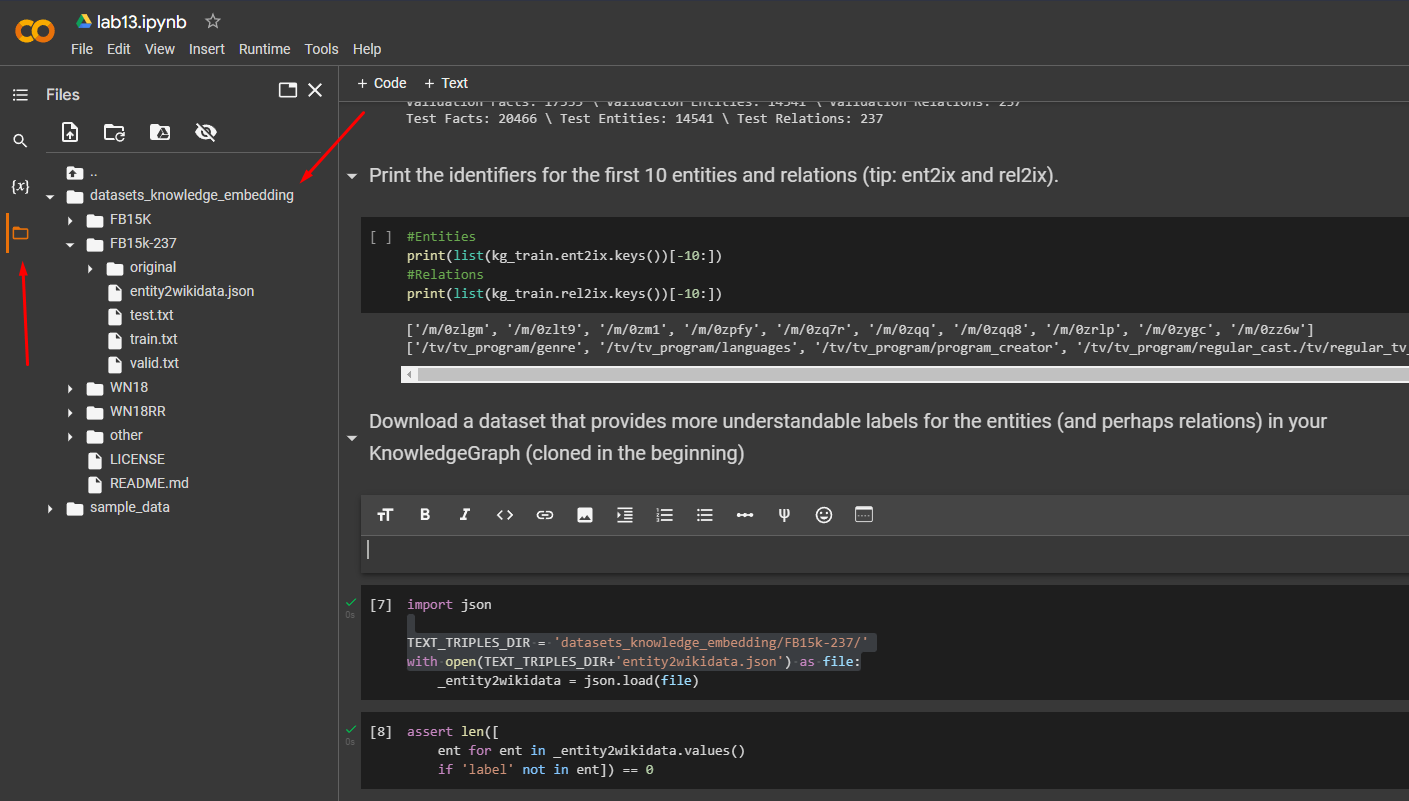

In [ ]:
import json

TEXT_TRIPLES_DIR = 'datasets_knowledge_embedding/FB15k-237/'
with open(TEXT_TRIPLES_DIR+'entity2wikidata.json') as file:
    _entity2wikidata = json.load(file)

## Create mappings from external label to entity (and perhaps relation) ids in the KnowledgeGraph. Also create the inverse mappings.

In [ ]:
ent2lbl = {
    ent: wd['label']
    for ent, wd in _entity2wikidata.items()
}

lbl2ent = {lbl: ent for ent, lbl in ent2lbl.items()}

In [ ]:
print([
    ent2lbl[ent]
    for ent in kg_train.ent2ix.keys()
    if ent in ent2lbl][-10:])

['Reading', 'Altoona', 'Anton Chekhov', 'Johnstown', 'Vertigo', 'canton of Aargau', 'State College', 'West Chester', 'Chester', 'Erie']


In [ ]:
#Your code here for relations

# **Test Entities and Relations:**

## Get the KG indexes for a few entities and relations. If you use the Freebase or Wikidata graphs, you can try 'J. K. Rowling' and 'WALL·E' as entities. For relations you can try 'influenced by' and 'genre'.

In [ ]:
#Your code here
#NOTE: You will ideally need more than one code box

#**Model**

##Load a [pre-trained TransE model](https://torchkge.readthedocs.io/en/latest/reference/utils.html#pre-trained-models) that matches your KnowledgeGraph

In [ ]:
#Your code here

###Print out the numbers of entities, relations, and the dimensions of the entity and relation vectors. Do they match your KnowledgeGraph.

In [ ]:
#Your code here

##Get the vectors for your test entities and relations (for example, 'J. K. Rowling' and 'influenced by'), also find vectors for a few more entities (both unrelated and related ones, e.g., 'J. R. R. Tolkien', 'C. S. Lewis', ...).

In [ ]:
#Your code here

##Use the [model.dissimilarity()-method](https://torchkge.readthedocs.io/en/latest/reference/models.html#translationalmodels) to estimate how semantically close your entities are. Do the distances make sense?

In [ ]:
#Your code here

#**K-nearest neighbours**

##Find the indexes of the 10 entity vectors that are nearest neighbours to your entity of choice. You can use [sciKit-learn's sklearn.neighbors.NearestNeighbors.kneighbors()-method](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html) for this.

In [ ]:
#Your code here

##Map the indexes of the 10-nearest neighbouring entities back into human-understandable labels. Does this make sense? Try the same thing with another entity (e.g., 'WALL·E').

In [ ]:
#Your code here
#NOTE: You will ideally need more than one code box

#**Translation**

##Add together the vectors for an entity and a relation that gives meaning for the entity. Find the 10-nearest neighbouring entities for the vector sum.

In [ ]:
#Your code here
#NOTE: You will ideally need more than one code box

##Try more entities and relations. Try to find examples that work and that do not work well.

In [ ]:
#Your code here